# Logistic regression
Logistic regression is a classification algorithm.

It will calculate a probability of the observed data to belong to a class. Its function indicates that an increase associated to a feature will indicate an increase in the likelihood of the observation belonging to a class.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../jupyter_notebooks/DATA/hearing_test.csv')
df

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1
...,...,...,...
4995,73.0,3.9,0
4996,57.0,33.9,1
4997,49.0,34.5,1
4998,38.0,46.4,1


In [3]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [4]:
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

<Axes: xlabel='test_result', ylabel='count'>

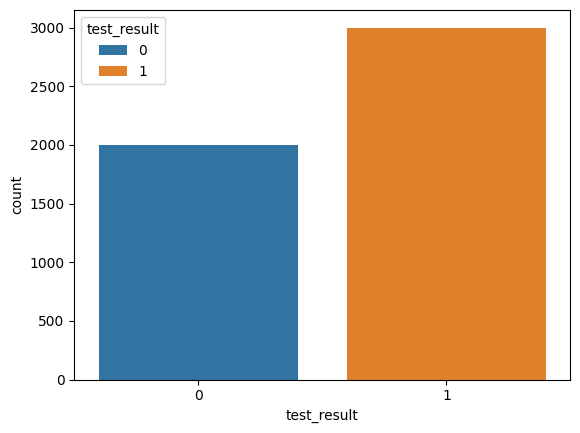

In [8]:
# compare the output pass/fail
sns.countplot(data = df, x='test_result', hue='test_result')

<Axes: xlabel='test_result', ylabel='age'>

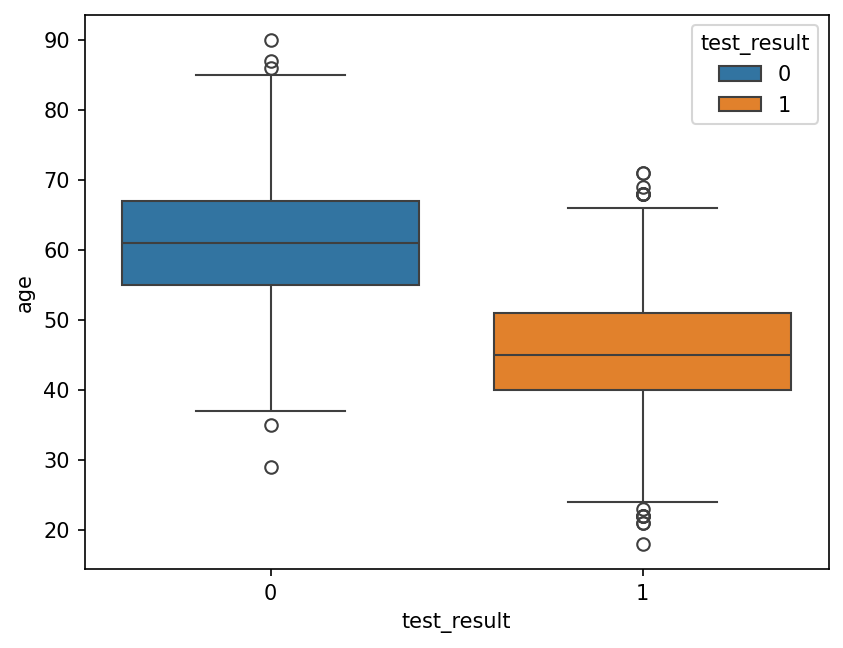

In [10]:
#Let's see the distribution of the test results against age
plt.figure(dpi=150)
sns.boxplot(x='test_result',y='age',data=df, hue='test_result')

<Axes: xlabel='test_result', ylabel='physical_score'>

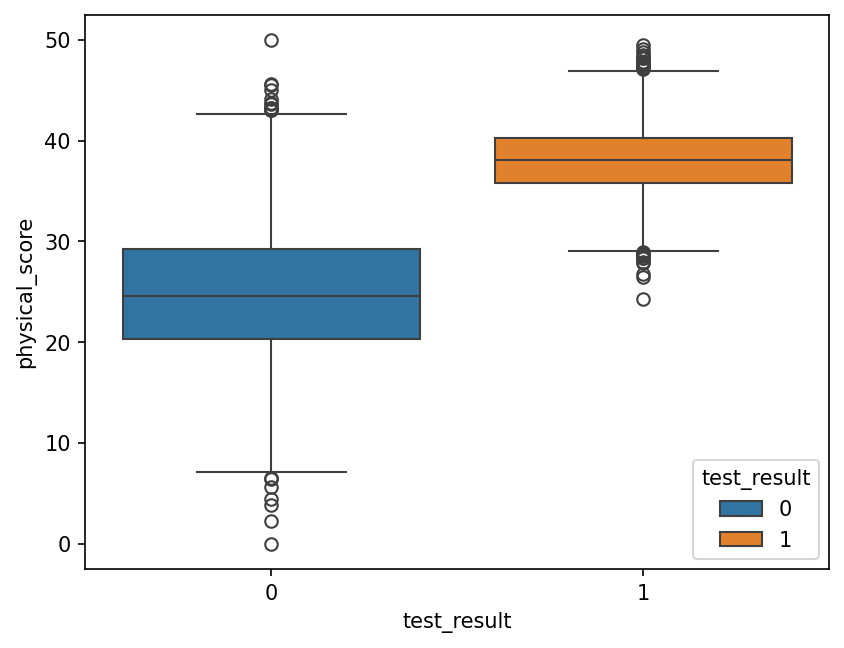

In [11]:
#It makes sense that older people fail the hearing test more often. Let's see if there is link also to physical condition
plt.figure(dpi=150)
sns.boxplot(x='test_result',y='physical_score',data=df, hue='test_result')

So, people with lower physical score, fail the hearing test more often.

Although there are people failing the hearing test in all the range of the physical score, you are more likely to pass the hearing test if you have a high physical score.

<Axes: xlabel='age', ylabel='physical_score'>

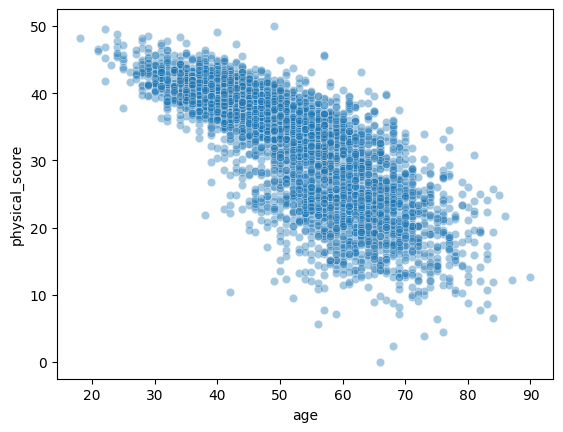

In [12]:
# Let's see the relation between age and physical score
sns.scatterplot(data=df, x='age', y='physical_score', alpha=0.4)

It looks like the physical score goes down with age.

Let's see the same graph with the pass/fail information added

<Axes: xlabel='age', ylabel='physical_score'>

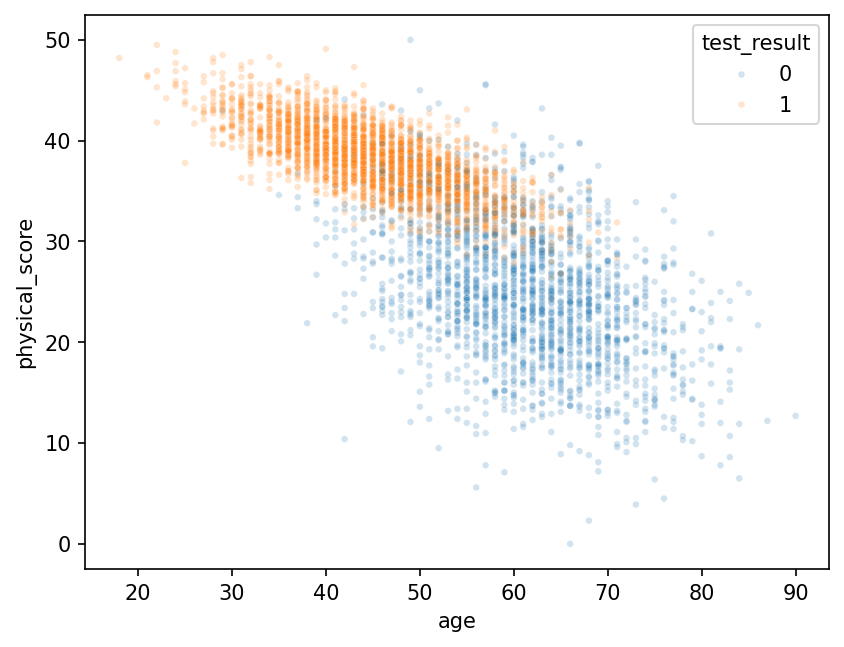

In [26]:
plt.figure(dpi=150)
sns.scatterplot(data=df, x='age', y='physical_score', alpha=0.2, hue='test_result', s=10)

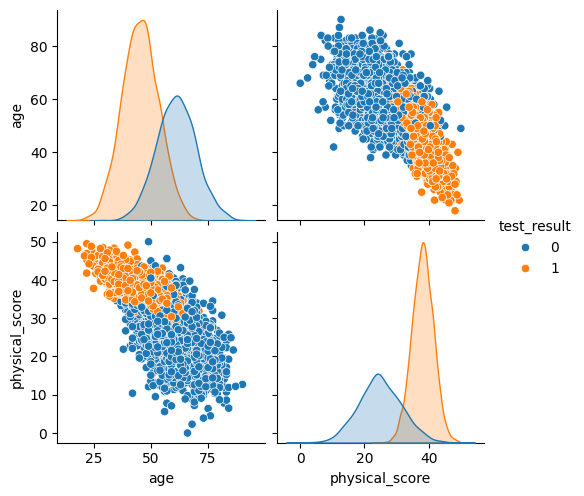

In [27]:
sns.pairplot(df,hue='test_result')

<Axes: >

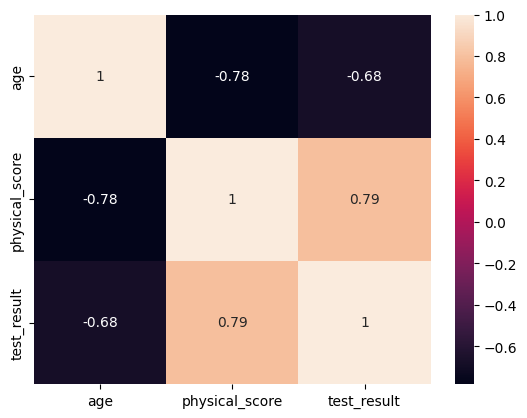

In [28]:
# Let's see how correlated the features are in a heatmap
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='physical_score', ylabel='test_result'>

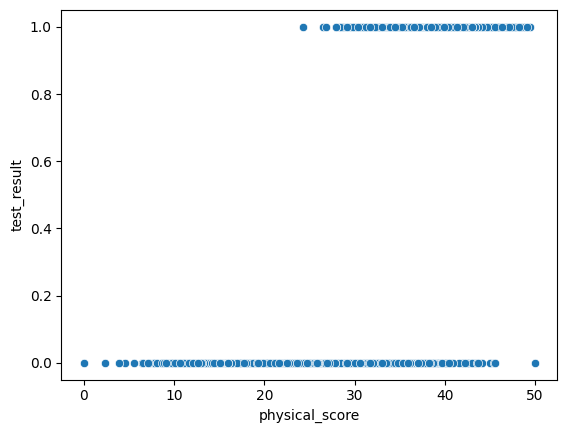

In [29]:
# Pay attention to choosing the features you plot, since they may result in a less-than-informative graph
sns.scatterplot(x='physical_score',y='test_result',data = df)

This shows the same as the first scatterplot, that people of all ages fail the test, but to pass the hearing test you better have a good physical score.

However, this plot does not look very informative. We can improve by adding a third dimension.

In [30]:
from mpl_toolkits.mplot3d import Axes3D

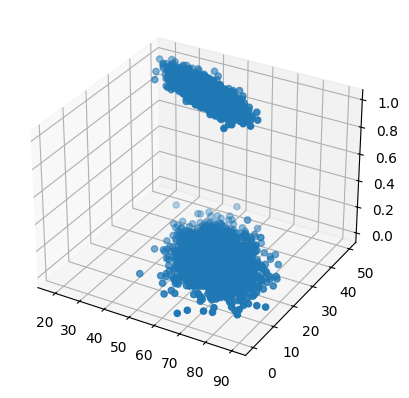

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['age'], df['physical_score'],df['test_result'])

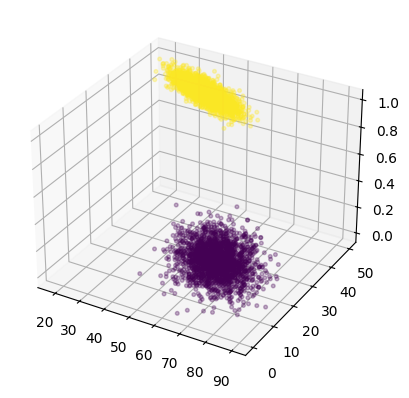

In [32]:
#Let's improve it a little bit:
#   Add alpha, reduce dot size, and make color depending o test result
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['age'], df['physical_score'],df['test_result'],alpha=0.3, s=7,c=df['test_result'])

In [33]:
X = df.drop('test_result',axis=1)
y = df['test_result']

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [35]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.1, random_state=101)

In [36]:
scaler = StandardScaler()

In [37]:
scaled_X_train = scaler.fit_transform(X_train)

In [38]:
scaled_X_test = scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
log_model = LogisticRegression()
log_model.fit(scaled_X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
log_model.coef_

array([[-0.95017725,  3.46148946]])

In [43]:
y_pred=log_model.predict(scaled_X_test)
y_pred

array([1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,

In [44]:
#if we wanted to get the probabilities of passing/failing the hearing test, we can use predict_proba
y_pred_prob=log_model.predict_proba(scaled_X_test)
y_pred_prob

array([[2.38051656e-02, 9.76194834e-01],
       [2.68854070e-02, 9.73114593e-01],
       [9.89220033e-01, 1.07799673e-02],
       [1.90238747e-03, 9.98097613e-01],
       [9.75065740e-01, 2.49342602e-02],
       [9.89676918e-01, 1.03230822e-02],
       [7.39558885e-02, 9.26044112e-01],
       [1.70641117e-02, 9.82935888e-01],
       [9.97075399e-01, 2.92460122e-03],
       [3.30092529e-02, 9.66990747e-01],
       [8.30393770e-02, 9.16960623e-01],
       [9.90796129e-03, 9.90092039e-01],
       [7.07374696e-03, 9.92926253e-01],
       [9.34320413e-01, 6.56795867e-02],
       [1.16096233e-04, 9.99883904e-01],
       [6.58212248e-02, 9.34178775e-01],
       [9.89155494e-01, 1.08445064e-02],
       [2.79291486e-03, 9.97207085e-01],
       [5.57001286e-04, 9.99442999e-01],
       [9.96534179e-01, 3.46582117e-03],
       [8.81902000e-01, 1.18098000e-01],
       [1.30963044e-01, 8.69036956e-01],
       [5.45789772e-01, 4.54210228e-01],
       [3.43636758e-02, 9.65636324e-01],
       [3.984685

which are pairs of (Probability of pertaining to the 0 (fail) class, probability of pertaining to the 1 (pass) class)